<a href="https://colab.research.google.com/github/Phoebe2777/Independent-Study-2025Fall/blob/main/Bella_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from pathlib import Path

In [3]:
# Original Code By Jayleen Jiang, Edited by Isabella Delmonte

# Output directory (change if needed)
OUTDIR = Path.home() / "Desktop" / "Altruism"
OUTDIR.mkdir(parents=True, exist_ok=True)

def path(name: str) -> Path:
    return OUTDIR / name

# Core Altruism Model
class AltruismModel:
    def __init__(self, alpha, K, base_interaction_rate, vP, vR,
                 dominance='dominant', discrimination='random',
                 fitness_mode='additive'):
        self.alpha = alpha
        self.K = K
        self.base_interaction_rate = base_interaction_rate
        self.vP = vP
        self.vR = vR
        self.dominance = dominance
        self.discrimination = discrimination
        self.fitness_mode = fitness_mode

    # Frequency-based helper functions
    def get_aP(self, A, N):
        total = A + N
        if total == 0:
            return 0
        p = A / total
        if self.dominance == 'recessive':
            return 1.0
        else:  # dominant
            q = 1 - p
            freq_AA = p ** 2
            freq_AN = 2 * p * q
            if freq_AA + freq_AN == 0:
                return 0
            return (2 * freq_AA + freq_AN) / (2 * (freq_AA + freq_AN))

    def get_aR(self, A, N):
        total = A + N
        if total == 0:
            return 0
        if self.discrimination == 'perfect':
            return 1.0
        elif self.discrimination == 'phenotype':
            return self.get_aP(A, N)
        else:
            return A / total  # random

    def get_interaction_rate(self, A, N):
        total = A + N
        if total == 0:
            return 0
        p = A / total
        population_size = total / 2  # diploid individuals
        if self.dominance == 'recessive':
            freq_altruists = p ** 2
        else:
            q = 1 - p
            freq_altruists = p ** 2 + 2 * p * q
        n = self.base_interaction_rate * freq_altruists * (population_size / self.K)
        return n

    # Differential equations
    def derivatives(self, t, y):
        A, N = y
        A = max(A, 0)
        N = max(N, 0)
        total = A + N
        if total == 0:
            return [0, 0]

        n = self.get_interaction_rate(A, N)
        aP = self.get_aP(A, N)
        aR = self.get_aR(A, N)
        logistic = 1 - total / self.K

        if self.fitness_mode == 'additive':
            dA_dt = self.alpha * A * logistic + n * (aP * self.vP + aR * self.vR)
            dN_dt = self.alpha * N * logistic + n * ((1 - aP) * self.vP + (1 - aR) * self.vR)
        else:  # multiplicative
            fA = (1 + self.alpha) * (1 + n * (aP * self.vP + aR * self.vR))
            fN = (1 + self.alpha) * (1 + n * ((1 - aP) * self.vP + (1 - aR) * self.vR))
            dA_dt = A * (fA - 1)
            dN_dt = N * (fN - 1)

        return [dA_dt, dN_dt]

    # Simulation runner
    def simulate(self, A0, N0, t_max=100, n_points=1000, freeze_N=False):
        t_span = (0, t_max)
        t_eval = np.linspace(0, t_max, n_points)
        y0 = [A0, N0]

        solution = solve_ivp(
            self.derivatives,
            t_span,
            y0,
            t_eval=t_eval,
            method='RK45',
            dense_output=True
        )

        A = solution.y[0]
        N = solution.y[1]
        if freeze_N:
            N = np.full_like(A, N0)

        return solution.t, A, N

    # Equilibrium & diagnostics
    def get_equilibrium_proportion(self):
        aP = 0.5
        aR = 0.5 if self.discrimination == 'random' else 1.0
        if self.vP + self.vR == 0:
            return None
        return (aP * self.vP + aR * self.vR) / (self.vP + self.vR)

    def dA_dt_components(self, A, N):
        total = A + N
        if total == 0:
            return 0, 0, 0
        n = self.get_interaction_rate(A, N)
        aP = self.get_aP(A, N)
        aR = self.get_aR(A, N)
        logistic = 1 - total / self.K
        growth_term = self.alpha * A * logistic
        interaction_term = n * (aP * self.vP + aR * self.vR)
        return growth_term, interaction_term, growth_term + interaction_term


# Run Scenarios
def run_scenario(title, alpha, K, n_base, vP, vR,
                 dominance, discrimination, A0, N0,
                 fitness_mode='additive', freeze_N=False):

    model = AltruismModel(alpha, K, n_base, vP, vR,
                          dominance, discrimination, fitness_mode)

    t, A, N = model.simulate(A0, N0, t_max=200, n_points=2000, freeze_N=freeze_N)
    total = A + N
    prop_A = A / total

    # --- Main plots (counts + proportions)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(t, A, label='A alleles (altruist)', linewidth=2)
    ax1.plot(t, N, label='N alleles (non-altruist)', linewidth=2)
    ax1.plot(t, total, label='Total alleles', linestyle='--', alpha=0.7)
    ax1.set_xlabel('Time'); ax1.set_ylabel('Number of alleles')
    ax1.set_title(f'{title}\nAllele counts over time', fontsize=13, fontweight='bold')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(t, prop_A, linewidth=2, color='darkblue')
    ax2.axhline(y=prop_A[-1], color='red', linestyle='--',
                label=f'Final: {prop_A[-1]:.3f}', alpha=0.7)
    eq_prop = model.get_equilibrium_proportion()
    if eq_prop is not None and 0 <= eq_prop <= 1:
        ax2.axhline(y=eq_prop, color='green', linestyle=':',
                    label=f'Theoretical eq: {eq_prop:.3f}', alpha=0.7)
    ax2.set_xlabel('Time'); ax2.set_ylabel('Proportion of A alleles')
    ax2.set_title('Proportion of altruist alleles', fontsize=13, fontweight='bold')
    ax2.set_ylim([0, 1]); ax2.legend(); ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Derivative diagnostic plot
    dA_vals = []
    for Ai, Ni in zip(A, N):
        _, _, dA_total = model.dA_dt_components(Ai, Ni)
        dA_vals.append(dA_total)

    plt.figure(figsize=(8, 4))
    plt.plot(t, dA_vals, color='purple', label='dA/dt')
    plt.axhline(0, color='black', linestyle='--', alpha=0.7)
    plt.title(f'{title}\nRate of Change of Altruist Alleles (dA/dt)', fontsize=13)
    plt.xlabel('Time'); plt.ylabel('dA/dt')
    plt.legend(); plt.grid(True, alpha=0.3)
    plt.show()

    return fig, (t, A, N, prop_A)

Scenario 1: Pure Altruism (vP < 0, vR > 0)
----------------------------------------------------------------------
  Cost to perpetrator: -0.5
  Benefit to recipient: 2.0
  Benefit/Cost ratio: 4.00


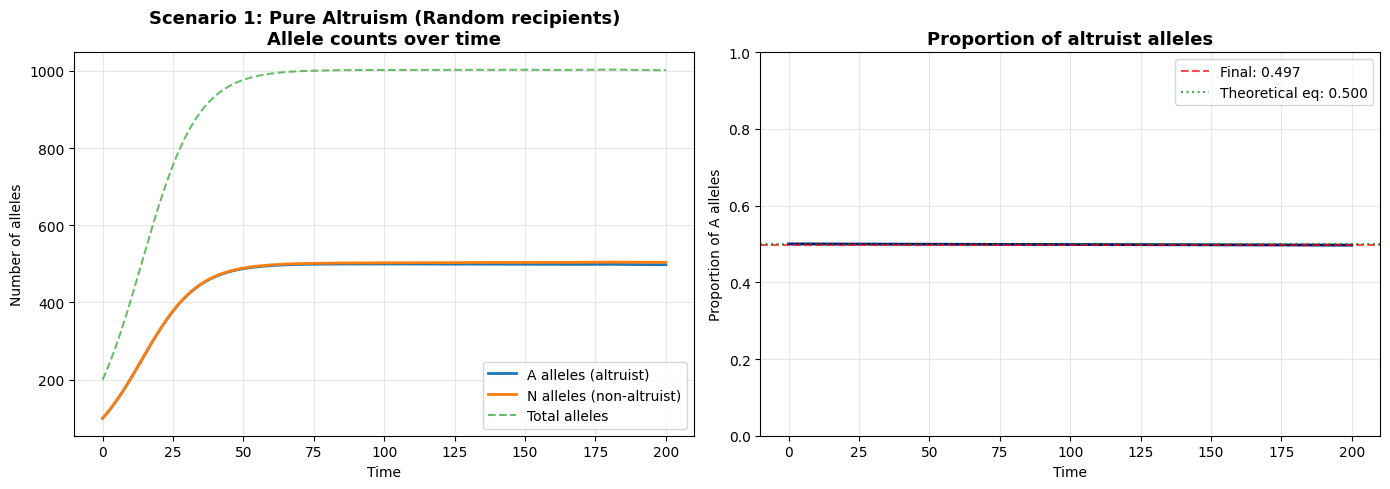

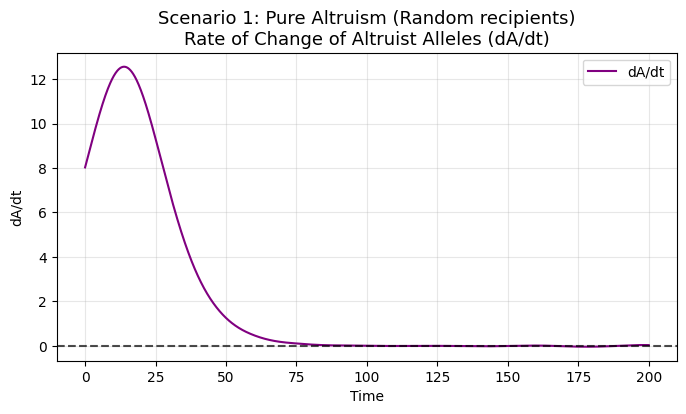

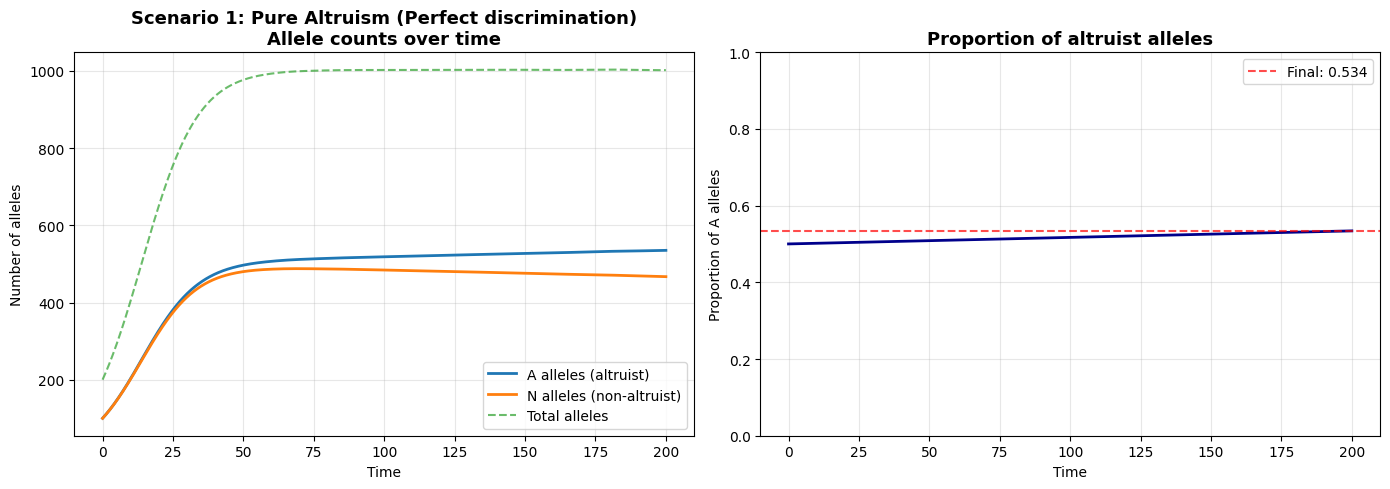

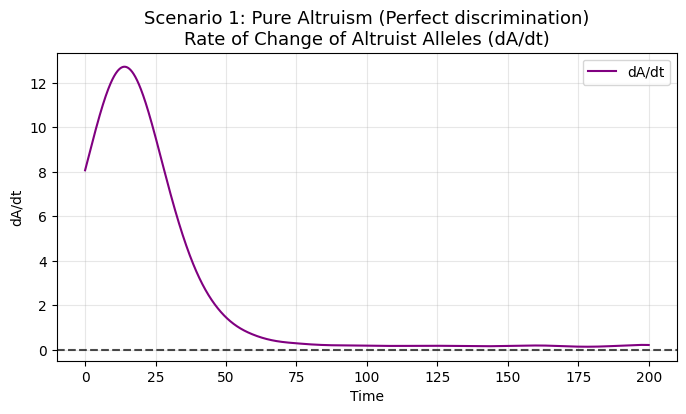


Scenario 2: Mutualism (vP > 0, vR > 0)
----------------------------------------------------------------------


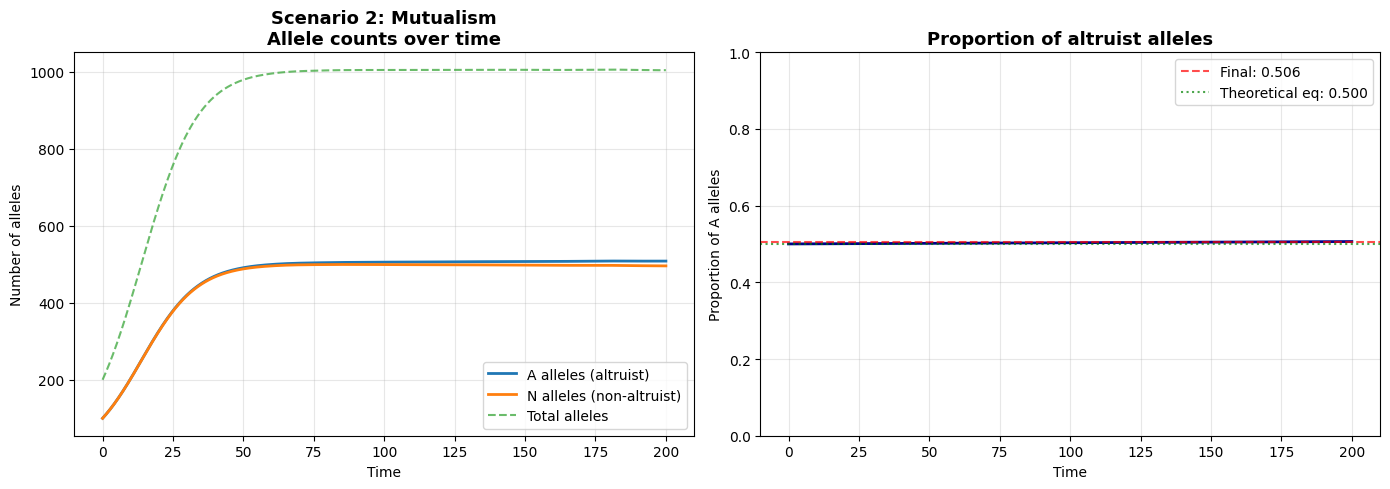

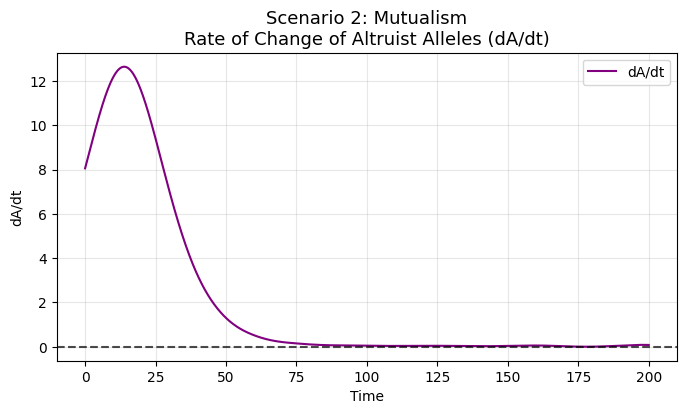


Scenario 3: Selfish Behavior (vP > 0, vR < 0)
----------------------------------------------------------------------


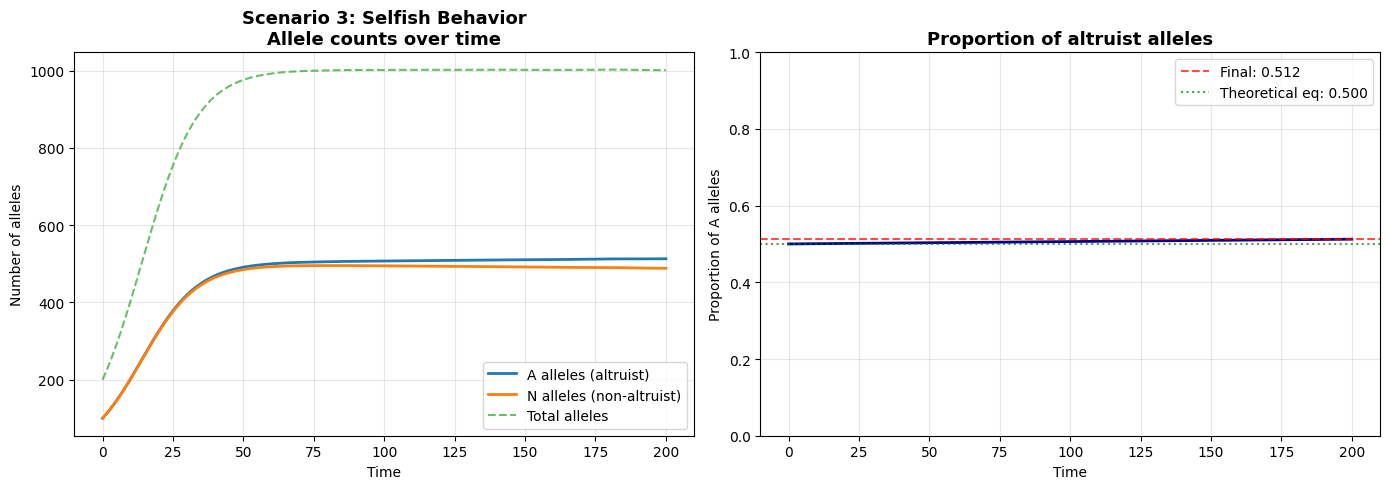

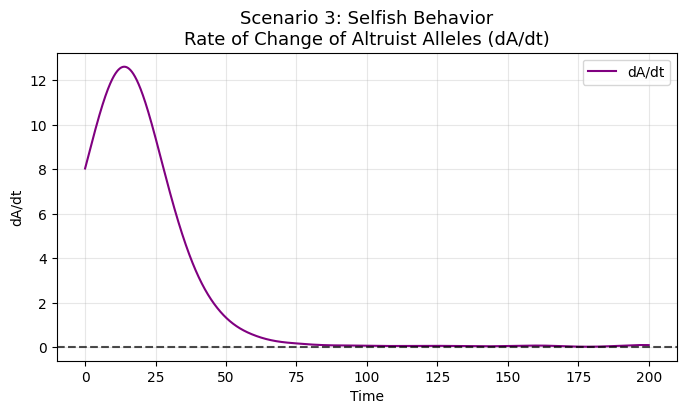


Scenario 4: Spiteful Behavior (vP < 0, vR < 0)
----------------------------------------------------------------------


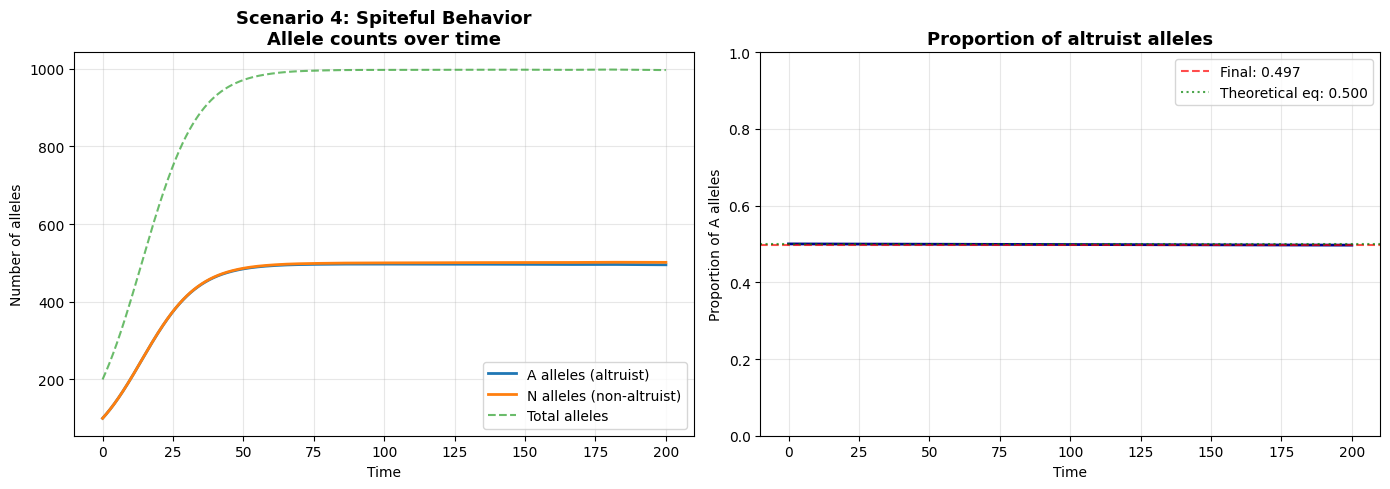

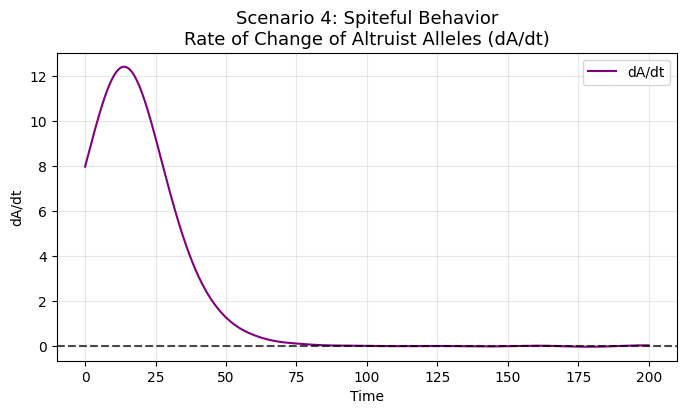


Scenario 5: Comparing Dominant vs Recessive Altruism
----------------------------------------------------------------------


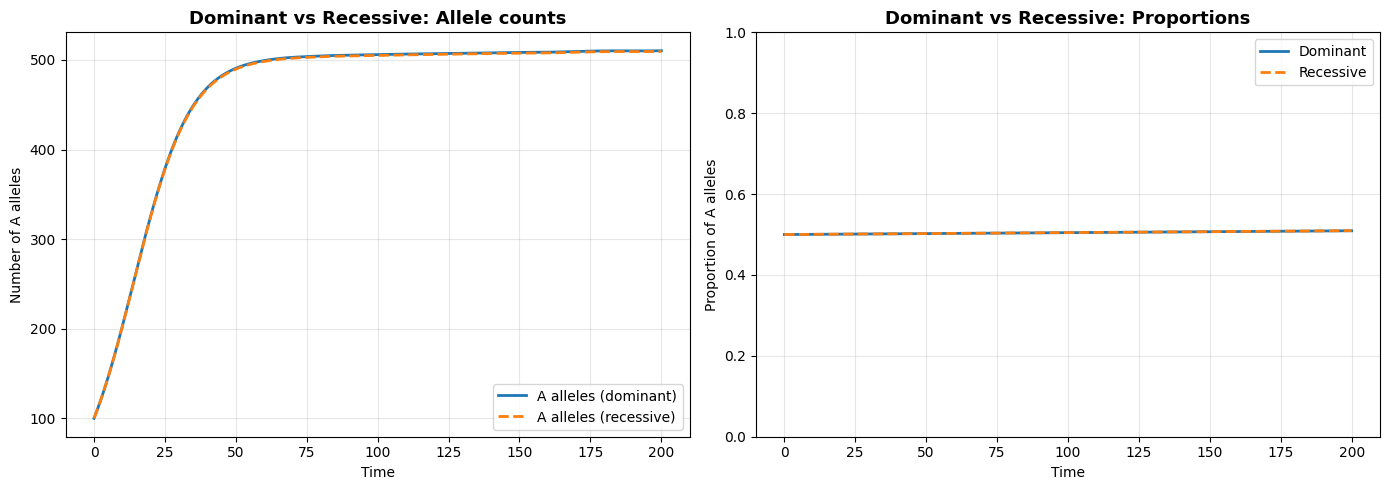

In [4]:

def main():
    alpha = 0.1
    K = 1000
    n_base = 0.5
    A0, N0 = 100, 100

    # Scenario 1: Pure altruism
    print("Scenario 1: Pure Altruism (vP < 0, vR > 0)")
    print("-" * 70)
    vP, vR = -0.5, 2.0
    print(f"  Cost to perpetrator: {vP}")
    print(f"  Benefit to recipient: {vR}")
    print(f"  Benefit/Cost ratio: {-vR / vP:.2f}")

    run_scenario("Scenario 1: Pure Altruism (Random recipients)",
                 alpha, K, n_base, vP, vR,
                 dominance='dominant', discrimination='random',
                 A0=A0, N0=N0, fitness_mode='additive')

    run_scenario("Scenario 1: Pure Altruism (Perfect discrimination)",
                 alpha, K, n_base, vP, vR,
                 dominance='dominant', discrimination='perfect',
                 A0=A0, N0=N0, fitness_mode='additive')

    # Scenario 2: Mutualism
    print("\nScenario 2: Mutualism (vP > 0, vR > 0)")
    print("-" * 70)
    vP, vR = 1.0, 1.5
    run_scenario("Scenario 2: Mutualism",
                 alpha, K, n_base, vP, vR,
                 dominance='dominant', discrimination='random',
                 A0=A0, N0=N0, fitness_mode='additive')

    # Scenario 3: Selfishness
    print("\nScenario 3: Selfish Behavior (vP > 0, vR < 0)")
    print("-" * 70)
    vP, vR = 2.0, -1.0
    run_scenario("Scenario 3: Selfish Behavior",
                 alpha, K, n_base, vP, vR,
                 dominance='dominant', discrimination='random',
                 A0=A0, N0=N0, fitness_mode='additive')

    # Scenario 4: Spite
    print("\nScenario 4: Spiteful Behavior (vP < 0, vR < 0)")
    print("-" * 70)
    vP, vR = -0.5, -1.0
    run_scenario("Scenario 4: Spiteful Behavior",
                 alpha, K, n_base, vP, vR,
                 dominance='dominant', discrimination='random',
                 A0=A0, N0=N0, fitness_mode='additive')

    # Scenario 5: Dominant vs Recessive comparison
    print("\nScenario 5: Comparing Dominant vs Recessive Altruism")
    print("-" * 70)
    vP, vR = -0.5, 2.0

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    model_dom = AltruismModel(alpha, K, n_base, vP, vR,
                              'dominant', 'phenotype')
    t_dom, A_dom, N_dom = model_dom.simulate(A0, N0, t_max=200)
    prop_dom = A_dom / (A_dom + N_dom)

    model_rec = AltruismModel(alpha, K, n_base, vP, vR,
                              'recessive', 'phenotype')
    t_rec, A_rec, N_rec = model_rec.simulate(A0, N0, t_max=200)
    prop_rec = A_rec / (A_rec + N_rec)

    ax1.plot(t_dom, A_dom, label='A alleles (dominant)', linewidth=2)
    ax1.plot(t_rec, A_rec, label='A alleles (recessive)', linestyle='--', linewidth=2)
    ax1.set_xlabel('Time'); ax1.set_ylabel('Number of A alleles')
    ax1.set_title('Dominant vs Recessive: Allele counts', fontsize=13, fontweight='bold')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(t_dom, prop_dom, label='Dominant', linewidth=2)
    ax2.plot(t_rec, prop_rec, label='Recessive', linestyle='--', linewidth=2)
    ax2.set_xlabel('Time'); ax2.set_ylabel('Proportion of A alleles')
    ax2.set_title('Dominant vs Recessive: Proportions', fontsize=13, fontweight='bold')
    ax2.set_ylim([0, 1]); ax2.legend(); ax2.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()


if __name__ == "__main__":
    main()

In [ ]:
# --- test dA/dt component plot ---
alpha, K, n_base, vP, vR = 0.1, 1000, 0.8, -0.5, 2.0
model = AltruismModel(alpha, K, n_base, vP, vR, 'dominant', 'random')
t, A, N = model.simulate(A0=100, N0=100, t_max=200)
growth, interact, total = [], [], []
for Ai, Ni in zip(A, N):
    g, inter, tot = model.dA_dt_components(Ai, Ni)
    growth.append(g); interact.append(inter); total.append(tot)

plt.figure(figsize=(9,4))
plt.plot(t, growth, label="logistic term αA(1 - (A+N)/K)")
plt.plot(t, interact, label="interaction term n(aP vP + aR vR)")
plt.plot(t, total, label="total dA/dt", linewidth=2, alpha=0.8)
plt.axhline(0, ls="--", c="k", alpha=0.6)
plt.title("dA/dt decomposition")
plt.xlabel("Time"); plt.ylabel("rate")
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()
